In [2]:
pip install Scikit-Image

   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
    --------------------------------------- 0.2/11.9 MB 5.3 MB/s eta 0:00:03
   - -------------------------------------- 0.5/11.9 MB 7.4 MB/s eta 0:00:02
   -- ------------------------------------- 0.6/11.9 MB 5.7 MB/s eta 0:00:02
   -- ------------------------------------- 0.6/11.9 MB 5.7 MB/s eta 0:00:02
   --- ------------------------------------ 1.0/11.9 MB 5.5 MB/s eta 0:00:02
   --- ------------------------------------ 1.0/11.9 MB 5.5 MB/s eta 0:00:02
   --- ------------------------------------ 1.0/11.9 MB 5.5 MB/s eta 0:00:02
   ----- ---------------------------------- 1.5/11.9 MB 4.2 MB/s eta 0:00:03
   ------ --------------------------------- 1.9/11.9 MB 4.6 MB/s eta 0:00:03
   ------- -------------------------------- 2.3/11.9 MB 5.1 MB/s eta 0:00:02
   --------- ------------------------------ 2.8/11.9 MB 5.6 MB/s eta 0:00:02
   ---------- ----------------------------- 3.1/11.9 MB 5.7 MB/s eta 0:00:02
   ---


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from sklearn.utils import shuffle
from skimage.transform import resize
from sklearn.metrics import confusion_matrix
import glob

In [5]:
cats=glob.glob('cat and dog/training_set/cats/*.jpg')
dogs = glob.glob('cat and dog/training_set/dogs/*.jpg')

In [6]:
cats_test = glob.glob('cat and dog/test_set/cats/*.jpg')
dogs_test = glob.glob('cat and dog/test_set/cats/*.jpg')

In [7]:
len(cats)

108

In [8]:
len(cats_test)

38

In [9]:
type(cats)

list

In [10]:
type(cats_test)

list

In [11]:
print("Number of images in Training are, Cats:",len(cats),",Dogs:",len(dogs))
print("Number of images in Testing are, Cats:",len(cats_test),",Dogs:",len(dogs_test))

print("Datatype of Training set, Cats:", type(cats),",Dogs:",type(dogs))
print("Datatype of Testing set, Cats:", type(cats_test),",Dogs:",type(dogs_test))

Number of images in Training are, Cats: 108 ,Dogs: 107
Number of images in Testing are, Cats: 38 ,Dogs: 38
Datatype of Training set, Cats: <class 'list'> ,Dogs: <class 'list'>
Datatype of Testing set, Cats: <class 'list'> ,Dogs: <class 'list'>


In [14]:
image = []
label = []

for i in cats:
    img = plt.imread(i)
    image.append(img)
    label.append(0)

    
for i in dogs:
    img = plt.imread(i)
    image.append(img)
    label.append(1)

In [15]:
image_test = []
label_test = []


for i in cats_test:
    img = plt.imread(i)
    image_test.append(img)
    label_test.append(0)

for i in dogs_test:
    img = plt.imread(i)
    image_test.append(img)
    label_test.append(1)

In [22]:
image,label = shuffle(image, label, random_state=100)

In [23]:
image_test, label_test = shuffle(image_test,label_test, random_state = 100)

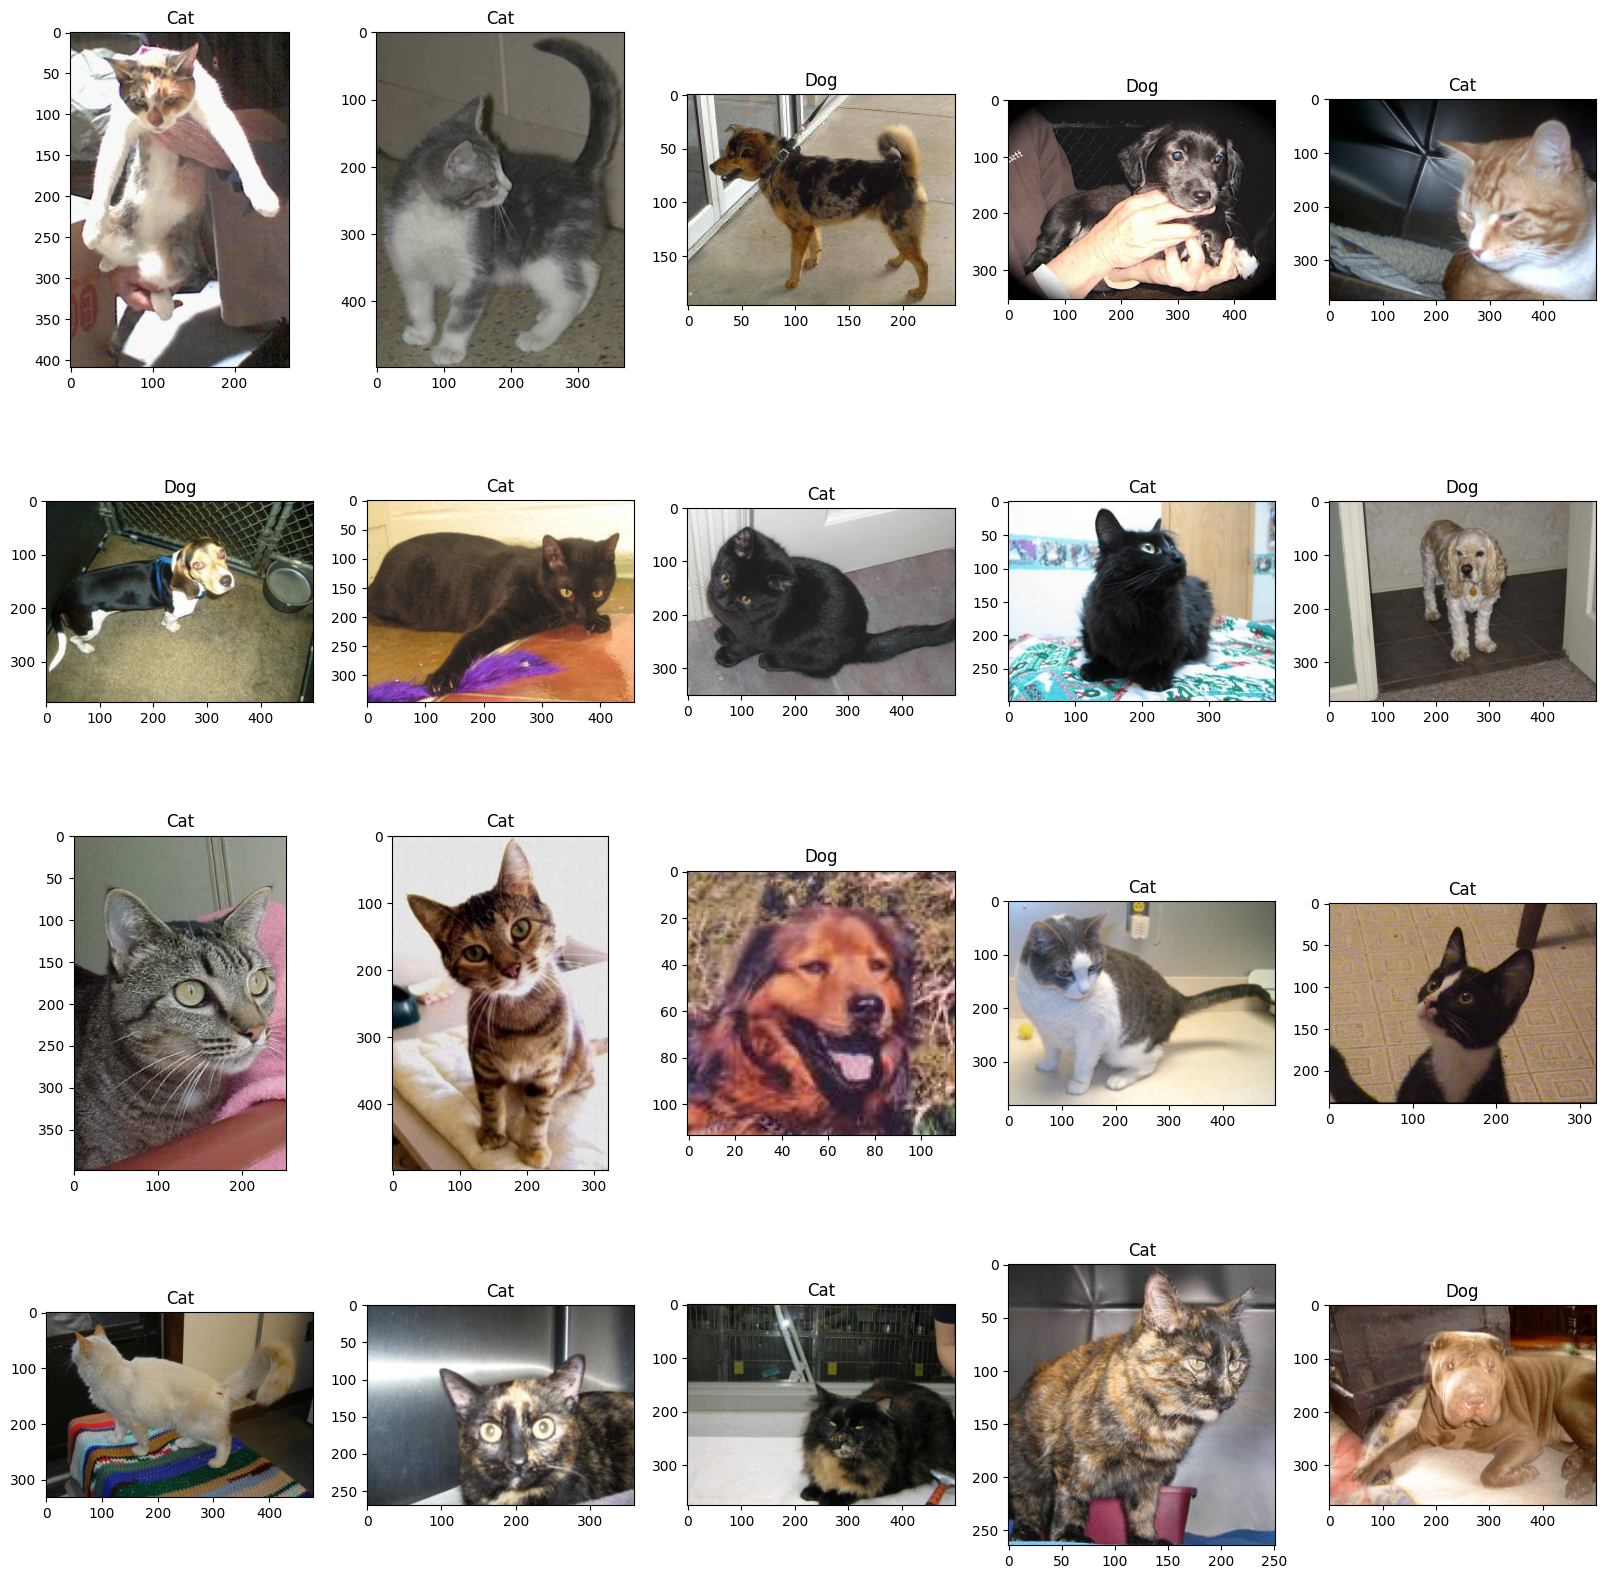

In [62]:
plt.figure(figsize = (20,20))
for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(image[i])
    if label[i] == 1:
        plt.title('Dog')
    else:
        plt.title('Cat')

In [33]:
X_train = []

for i in image:
    X_train.append(resize(i,(64,64,3)))
    
X_train = np.array(X_train)

In [34]:
X_test = []

for i in image_test:
    X_test.append(resize(i,(64,64,3)))
    
X_test = np.array(X_test)

In [39]:
y_train = np.array(label)
y_test = np.array(label_test)

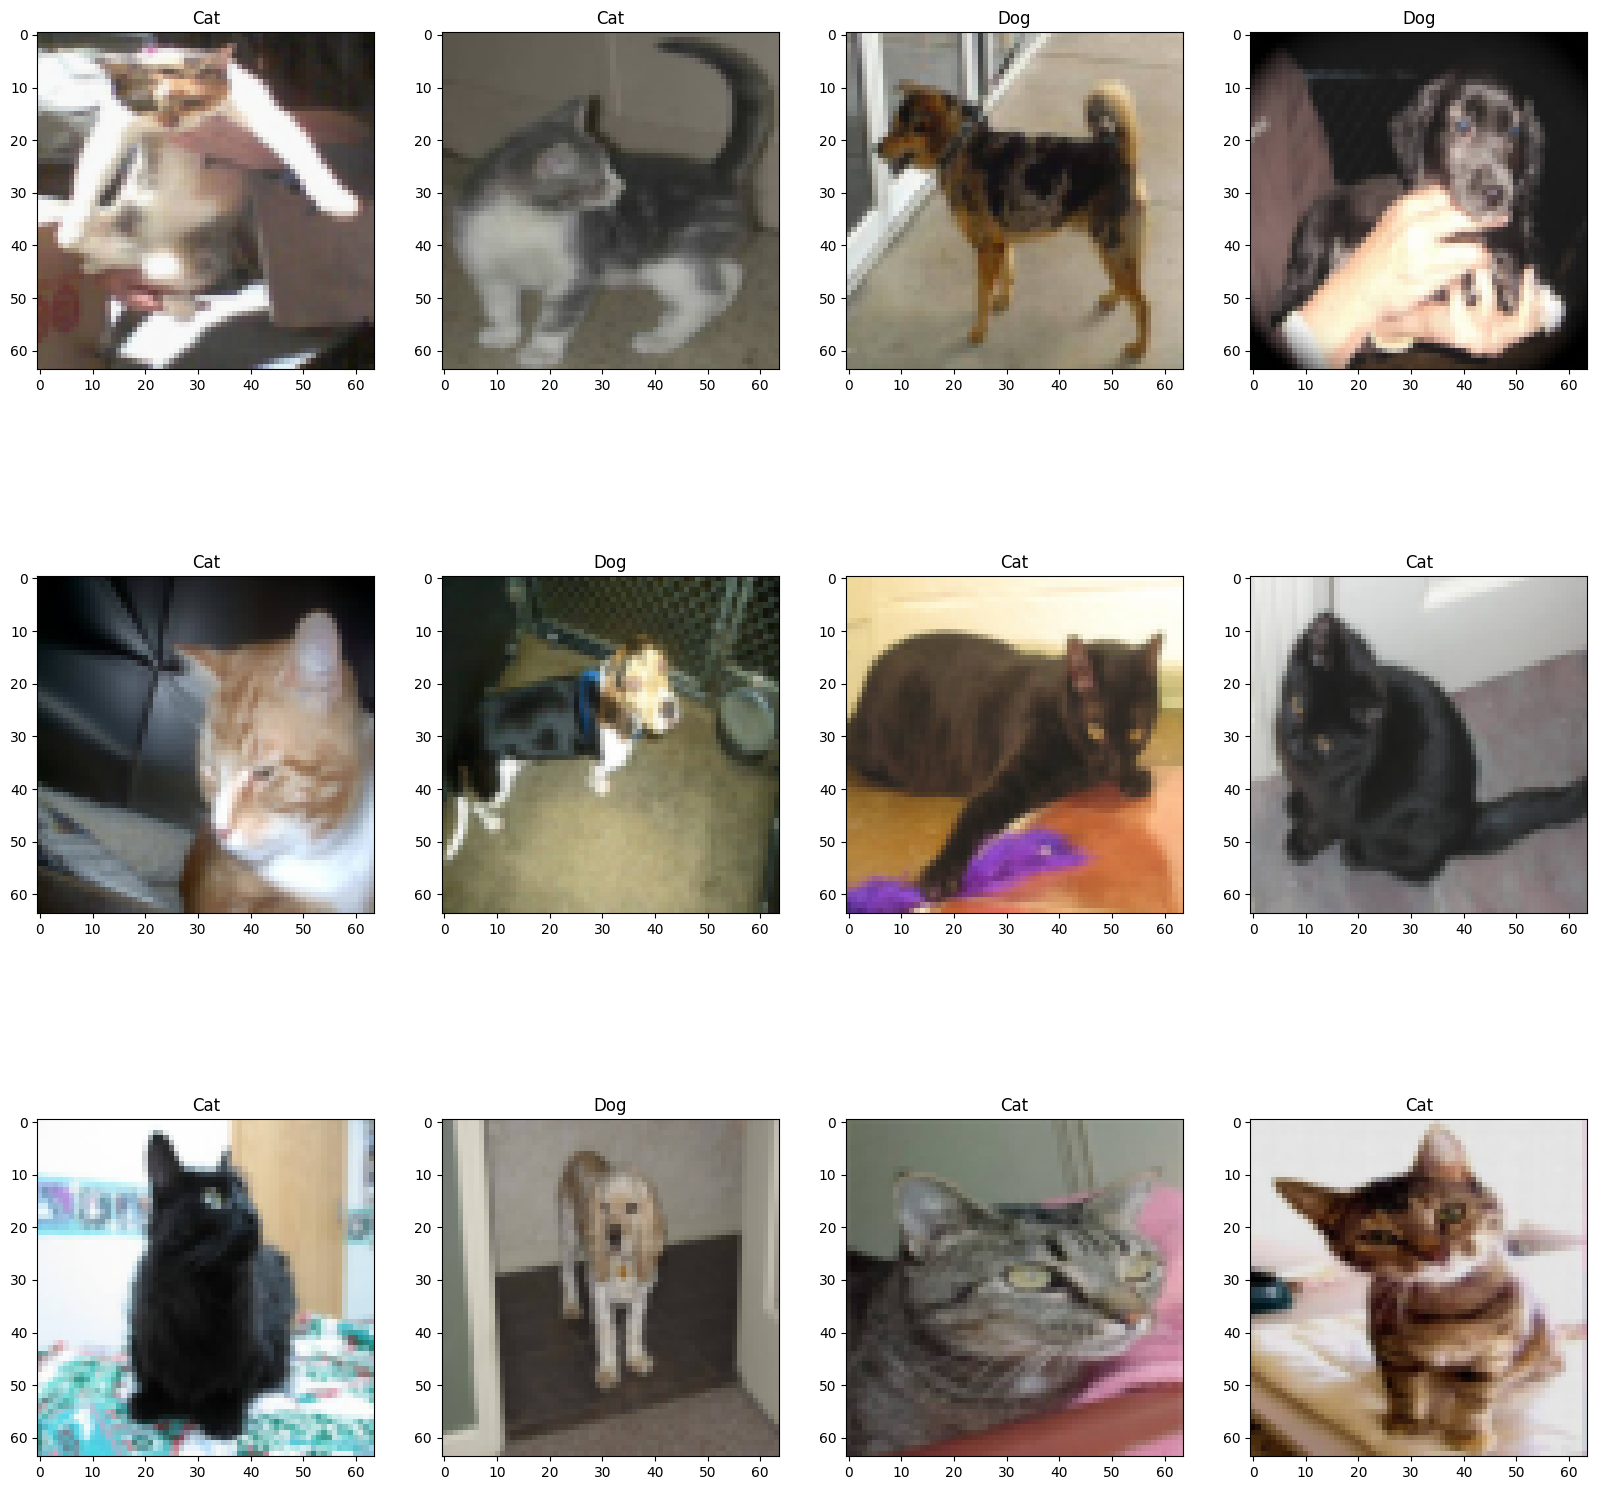

In [40]:
plt.figure(figsize = (20,20))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_train[i])
    if y_train[i] == 1:
        plt.title('Dog')
    else:
        plt.title('Cat')





In [41]:
print(type(y_train))
print(type(y_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [43]:
print(X_train.shape)
print(y_train.shape)

(215, 64, 64, 3)
(215,)


In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
model = keras.models.Sequential([
    keras.layers.Conv2D(16, (3,3), activation = 'relu', input_shape = (64, 64, 3)),
    keras.layers.MaxPool2D(2,2),
    
    keras.layers.Conv2D(32,(3,3), activation = 'relu'),
    keras.layers.MaxPool2D(2,2),
    
    keras.layers.Flatten(),
    
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dense(1, activation = 'sigmoid')
])

C:\Users\anjal\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
model.compile(optimizer = 'adam',
             loss = 'binary_crossentropy',
             metrics = ['accuracy'])

In [50]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         401,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 406,625 (1.55 MB)

 Trainable params: 406,625 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model.fit(X_train,y_train, epochs=30, steps_per_epoch=3, validation_split=0.1)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.4767 - loss: 0.7760 - val_accuracy: 0.4545 - val_loss: 0.7250
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5078 - loss: 0.7129 - val_accuracy: 0.4545 - val_loss: 0.7456
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5078 - loss: 0.7058 - val_accuracy: 0.4545 - val_loss: 0.7209
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5078 - loss: 0.6953 - val_accuracy: 0.4545 - val_loss: 0.6939
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5130 - loss: 0.6907 - val_accuracy: 0.5455 - val_loss: 0.6865
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.4974 - loss: 0.6879 - val_accuracy: 0.5455 - val_loss: 0.6874
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5026 - loss: 0.6814 - val_accuracy: 0.4545 - val_loss: 0.6954
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5440 - loss: 0.6728 - val_accuracy: 0.3636 - val_loss: 0.7027

In [52]:
model.evaluate(X_train, y_train)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9349 - loss: 0.2404 


[0.24037684500217438, 0.934883713722229]

In [53]:
prediction = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [54]:
prediction[:5]

array([[0.8165143 ],
       [0.30859625],
       [0.03260779],
       [0.00379181],
       [0.17953707]], dtype=float32)

In [55]:
pred = []

for i in prediction:
    if i > 0.5:
        pred.append(0)
    else:
        pred.append(1)

In [56]:
pred

[0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1]

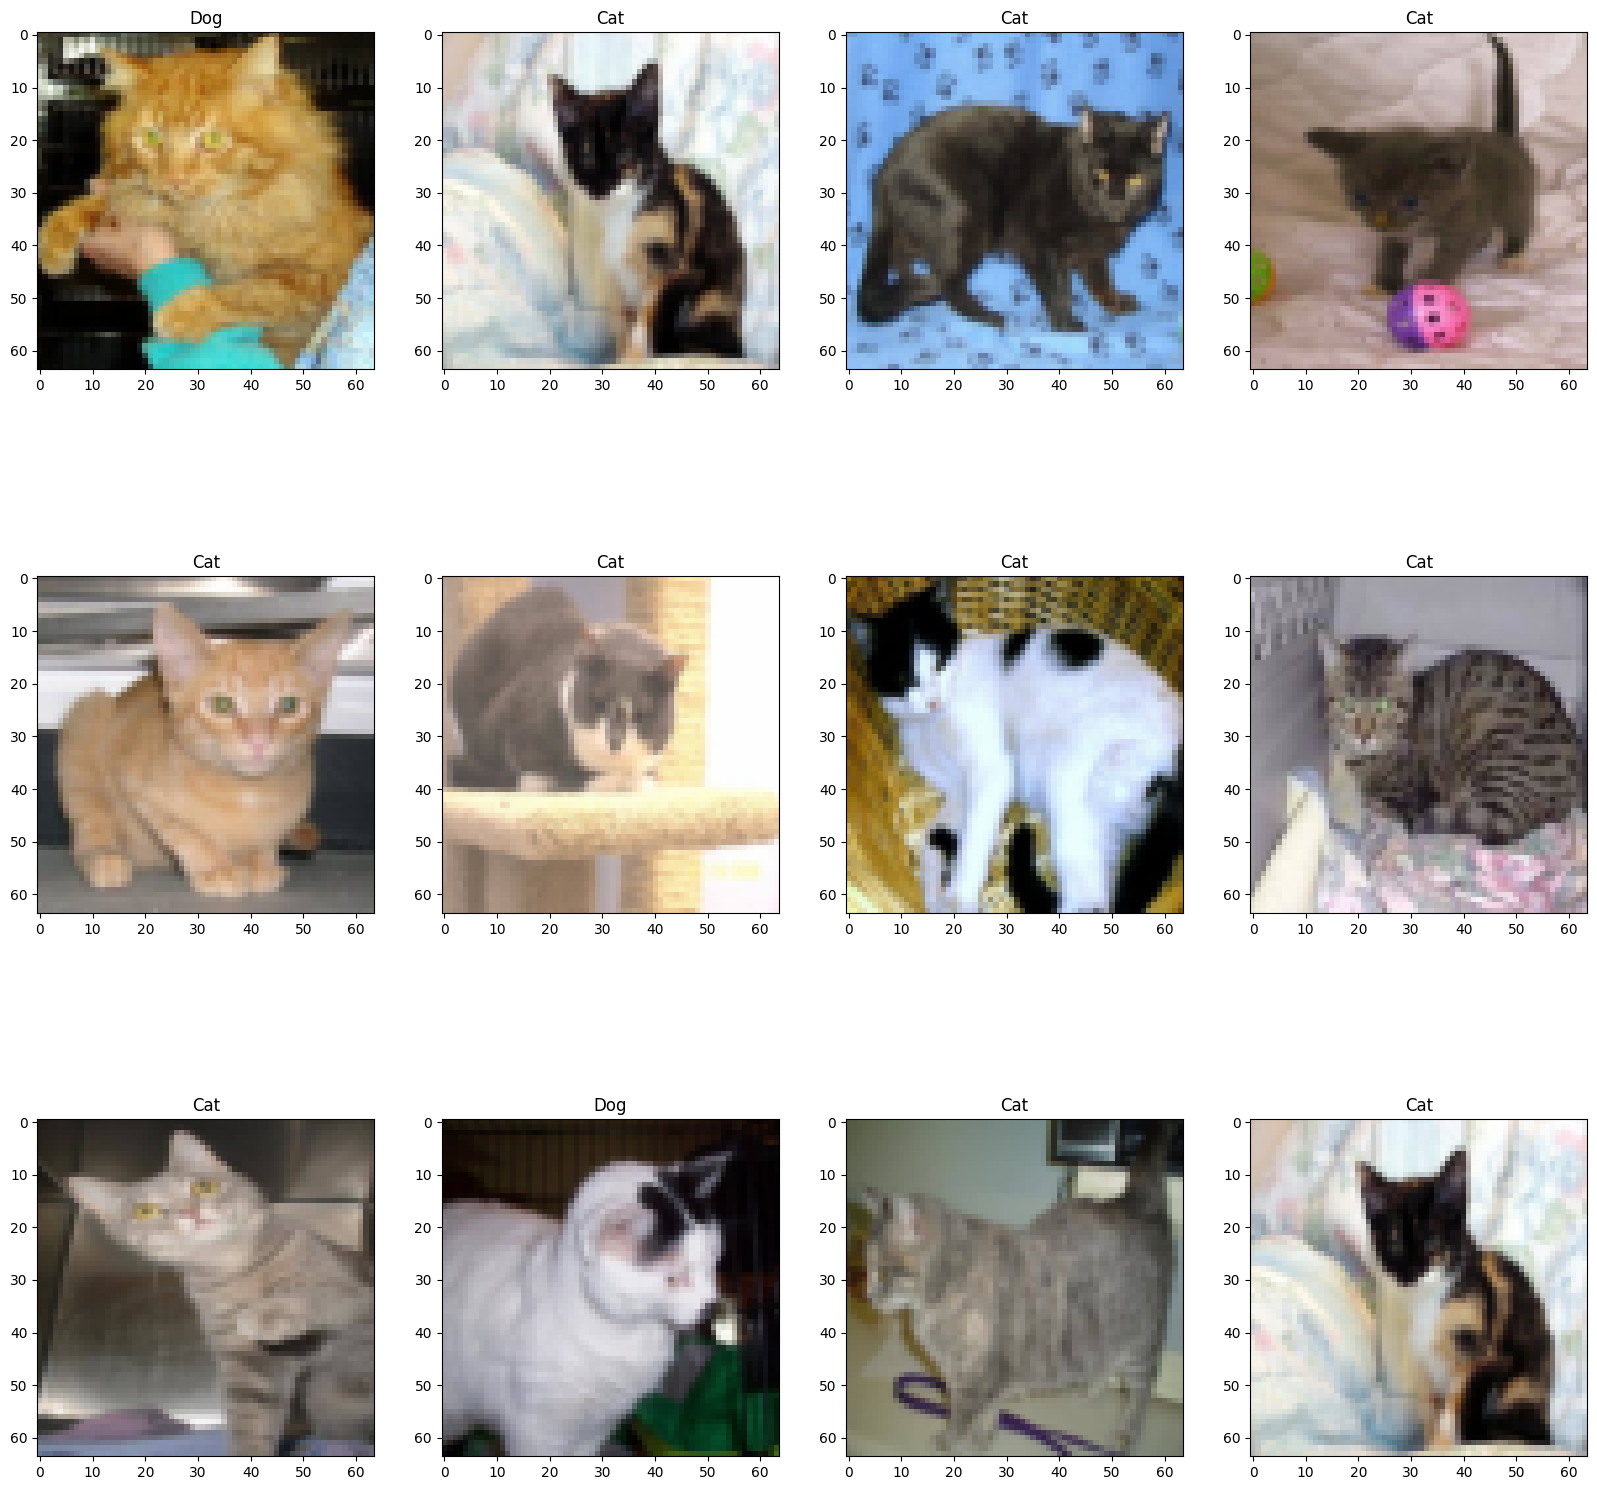

In [59]:
plt.figure(figsize = (20,20))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[i])
    if pred[i] == 1:
        plt.title('Cat')
    else:
        plt.title('Dog')

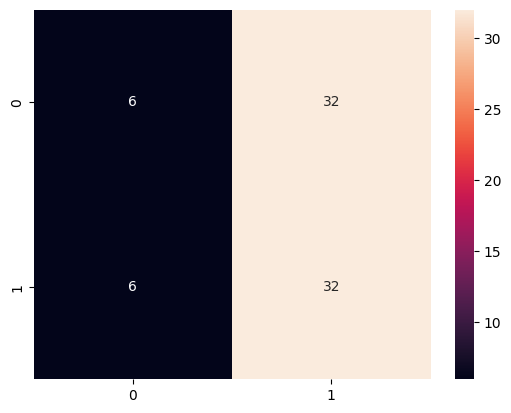

In [58]:
sns.heatmap(confusion_matrix(y_test,pred), annot = True)
plt.show()